In [ ]:
/Users/tatiana/Documents_new/pang/visor_freqk/summaries/results.ipynb

# rm -rf beds/* haplotypes/* reads/* vcf/*

In [ ]:
# there might be a problem with this 

tbellagio@login1:~/scratch/pang/visor_freqk$ python scripts/launch_experiment.py --sv-type DEL --coverage 50 --freq 0.10

In [ ]:
python scripts/launch_experiment.py --sv-type DEL --coverage 50 --freq 0.10
python scripts/launch_experiment.py --sv-type INS --coverage 50 --freq 0.10

python scripts/launch_experiment.py --sv-type DEL --coverage 50 --freq 0.30
python scripts/launch_experiment.py --sv-type INS --coverage 50 --freq 0.30

python scripts/launch_experiment.py --sv-type DEL --coverage 20 --freq 0.10
python scripts/launch_experiment.py --sv-type INS --coverage 20 --freq 0.10

python scripts/launch_experiment.py --sv-type DEL --coverage 20 --freq 0.30
python scripts/launch_experiment.py --sv-type INS --coverage 20 --freq 0.30

python scripts/launch_experiment.py --sv-type DEL --coverage 10 --freq 0.10
python scripts/launch_experiment.py --sv-type INS --coverage 10 --freq 0.10

python scripts/launch_experiment.py --sv-type DEL --coverage 10 --freq 0.30
python scripts/launch_experiment.py --sv-type INS --coverage 10 --freq 0.30



In [2]:
import os
import glob
from pathlib import Path
import pandas as pd

# Base results directory
# New layout: results/{sv_type}/{cov_err}/{SV_TYPE}/{size}/{freq}/{k}/
# cov_err encodes coverage and full error rate after the decimal (e.g. cov20_err0, cov20_err001)
results_dir = Path('/Users/tatiana/Documents_new/pang/visor_freqk/results')

# Find all allele frequency files recursively (any k value)
allele_freq_files = sorted(results_dir.rglob('*.allele_frequencies.k*.tsv'))

print(f"Found {len(allele_freq_files)} allele frequency files:\n")
print(f"{'SV':4s}  {'cov/err':12s}  {'size':6s}  {'freq':4s}  {'k':4s}  file")
print("-" * 75)

for f in allele_freq_files:
    parts = f.relative_to(results_dir).parts
    # parts: (sv_type, cov_err, SV_TYPE, size, freq, k, filename)
    sv_type = parts[2]   # 'DEL' or 'INS'
    cov_err = parts[1]   # 'cov50_err0'
    size    = parts[3]   # '100bp', '1kb', ...
    freq    = parts[4]   # 'f50'
    k       = parts[5]   # 'k31'
    print(f"{sv_type:4s}  {cov_err:12s}  {size:6s}  {freq:4s}  {k:4s}  {f.name}")

print(f"\nTotal: {len(allele_freq_files)} files")
print("\n" + "="*80)
print("Full paths:")
print("="*80)
for f in allele_freq_files:
    print(f)


Found 40 allele frequency files:

SV    cov/err       size    freq  k     file
---------------------------------------------------------------------------
DEL   cov10_err001  100bp   f50   k31   freq_100bp_f50_err001.allele_frequencies.k31.tsv
DEL   cov10_err001  10kb    f50   k31   freq_10kb_f50_err001.allele_frequencies.k31.tsv
DEL   cov10_err001  1kb     f50   k31   freq_1kb_f50_err001.allele_frequencies.k31.tsv
DEL   cov10_err001  500bp   f50   k31   freq_500bp_f50_err001.allele_frequencies.k31.tsv
DEL   cov10_err001  5kb     f50   k31   freq_5kb_f50_err001.allele_frequencies.k31.tsv
DEL   cov20_err001  100bp   f50   k31   freq_100bp_f50_err001.allele_frequencies.k31.tsv
DEL   cov20_err001  10kb    f50   k31   freq_10kb_f50_err001.allele_frequencies.k31.tsv
DEL   cov20_err001  1kb     f50   k31   freq_1kb_f50_err001.allele_frequencies.k31.tsv
DEL   cov20_err001  500bp   f50   k31   freq_500bp_f50_err001.allele_frequencies.k31.tsv
DEL   cov20_err001  5kb     f50   k31   freq_5kb_f50

In [3]:
rows = []

for f in allele_freq_files:
    parts = f.relative_to(results_dir).parts
    # parts: (sv_root, cov_err, SV_TYPE, size, freq, k, filename)
    sv_root = parts[0]      # 'del' or 'ins'
    cov_err = parts[1]      # e.g. 'cov20_err0', 'cov20_err001'
    sv_type = parts[2]      # 'DEL' or 'INS'
    size    = parts[3]      # '100bp', '1kb', ...
    freq_lbl= parts[4]      # 'f50'
    k_lbl   = parts[5]      # 'k31'

    # Parse coverage / error from cov_err
    cov_part, err_part = cov_err.split('_')  # 'cov20', 'err0'
    coverage = int(cov_part.replace('cov', ''))
    error_rate = float(err_part.replace('err', '')) / 100.0  # 0 -> 0.0, 0.1 -> 0.001, etc.

    # Parse nominal allele frequency from label (e.g. f50 -> 0.5)
    freq_nominal = int(freq_lbl.replace('f', '')) / 100.0

    # Parse k from k-label (e.g. k31 -> 31)
    k = int(k_lbl.replace('k', ''))

    # Read AF line (it is a single line like '0.6|0.4')
    line = f.read_text().strip()
    parts_af = line.split('|')
    # Pad to at least 2 entries
    if len(parts_af) == 1:
        parts_af = parts_af + ['nan']
    af_ref = float(parts_af[0])
    af_alt = float(parts_af[1])

    rows.append({
        'sv_root': sv_root,
        'sv_type': sv_type,
        'cov_err': cov_err,
        'coverage': coverage,
        'error_rate': error_rate,
        'size': size,
        'freq_label': freq_lbl,
        'freq_nominal': freq_nominal,
        'k_label': k_lbl,
        'k': k,
        'file': str(f),
        'af_ref': af_ref,
        'af_alt': af_alt,
    })

results_df = pd.DataFrame(rows)
results_df

,sv_root,sv_type,cov_err,coverage,error_rate,size,freq_label,freq_nominal,k_label,k,file,af_ref,af_alt
0,del,DEL,cov10_err001,10,0.01,100bp,f50,0.5,k31,31,/Users/tatiana/Documents_new/pang/visor_freqk/...,0.620579,0.379421
1,del,DEL,cov10_err001,10,0.01,10kb,f50,0.5,k31,31,/Users/tatiana/Documents_new/pang/visor_freqk/...,0.566950,0.433050
2,del,DEL,cov10_err001,10,0.01,1kb,f50,0.5,k31,31,/Users/tatiana/Documents_new/pang/visor_freqk/...,0.728059,0.271941
3,del,DEL,cov10_err001,10,0.01,500bp,f50,0.5,k31,31,/Users/tatiana/Documents_new/pang/visor_freqk/...,0.619355,0.380645
4,del,DEL,cov10_err001,10,0.01,5kb,f50,0.5,k31,31,/Users/tatiana/Documents_new/pang/visor_freqk/...,0.547432,0.452568
5,del,DEL,cov20_err001,20,0.01,100bp,f50,0.5,k31,31,/Users/tatiana/Documents_new/pang/visor_freqk/...,0.349414,0.650586
6,del,DEL,cov20_err001,20,0.01,10kb,f50,0.5,k31,31,/Users/tatiana/Documents_new/pang/visor_freqk/...,0.556867,0.443133
7,del,DEL,cov20_err001,20,0.01,1kb,f50,0.5,k31,31,/Users/tatiana/Documents_new/pang/visor_freqk/...,0.456449,0.543551
8,del,DEL,cov20_err001,20,0.01,500bp,f50,0.5,k31,31,/Users/tatiana/Documents_new/pang/visor_freqk/...,0.488409,0.511591
9,del,DEL,cov20_err001,20,0.01,5kb,f50,0.5,k31,31,/Users/tatiana/Documents_new/pang/visor_freqk/...,0.386087,0.613913


In [4]:
results_df.sort_values(['sv_type','coverage'])

,sv_root,sv_type,cov_err,coverage,error_rate,size,freq_label,freq_nominal,k_label,k,file,af_ref,af_alt
0,del,DEL,cov10_err001,10,0.01,100bp,f50,0.5,k31,31,/Users/tatiana/Documents_new/pang/visor_freqk/...,0.620579,0.379421
1,del,DEL,cov10_err001,10,0.01,10kb,f50,0.5,k31,31,/Users/tatiana/Documents_new/pang/visor_freqk/...,0.566950,0.433050
2,del,DEL,cov10_err001,10,0.01,1kb,f50,0.5,k31,31,/Users/tatiana/Documents_new/pang/visor_freqk/...,0.728059,0.271941
3,del,DEL,cov10_err001,10,0.01,500bp,f50,0.5,k31,31,/Users/tatiana/Documents_new/pang/visor_freqk/...,0.619355,0.380645
4,del,DEL,cov10_err001,10,0.01,5kb,f50,0.5,k31,31,/Users/tatiana/Documents_new/pang/visor_freqk/...,0.547432,0.452568
5,del,DEL,cov20_err001,20,0.01,100bp,f50,0.5,k31,31,/Users/tatiana/Documents_new/pang/visor_freqk/...,0.349414,0.650586
6,del,DEL,cov20_err001,20,0.01,10kb,f50,0.5,k31,31,/Users/tatiana/Documents_new/pang/visor_freqk/...,0.556867,0.443133
7,del,DEL,cov20_err001,20,0.01,1kb,f50,0.5,k31,31,/Users/tatiana/Documents_new/pang/visor_freqk/...,0.456449,0.543551
8,del,DEL,cov20_err001,20,0.01,500bp,f50,0.5,k31,31,/Users/tatiana/Documents_new/pang/visor_freqk/...,0.488409,0.511591
9,del,DEL,cov20_err001,20,0.01,5kb,f50,0.5,k31,31,/Users/tatiana/Documents_new/pang/visor_freqk/...,0.386087,0.613913


In [5]:
import seaborn as sns

In [6]:
# ── Compute error metrics ──────────────────────────────────────────────────────
results_df["error"]     = results_df["af_alt"] - results_df["freq_nominal"]   # signed bias
results_df["abs_error"] = results_df["error"].abs()
results_df["rel_error"] = results_df["abs_error"] / results_df["freq_nominal"]

results_df[["sv_type","coverage","error_rate","size","freq_nominal","af_alt","error","abs_error"]].head(10)


,sv_type,coverage,error_rate,size,freq_nominal,af_alt,error,abs_error
0,DEL,10,0.01,100bp,0.5,0.379421,-0.120579,0.120579
1,DEL,10,0.01,10kb,0.5,0.433050,-0.066950,0.066950
2,DEL,10,0.01,1kb,0.5,0.271941,-0.228059,0.228059
3,DEL,10,0.01,500bp,0.5,0.380645,-0.119355,0.119355
4,DEL,10,0.01,5kb,0.5,0.452568,-0.047432,0.047432
5,DEL,20,0.01,100bp,0.5,0.650586,0.150586,0.150586
6,DEL,20,0.01,10kb,0.5,0.443133,-0.056867,0.056867
7,DEL,20,0.01,1kb,0.5,0.543551,0.043551,0.043551
8,DEL,20,0.01,500bp,0.5,0.511591,0.011591,0.011591
9,DEL,20,0.01,5kb,0.5,0.613913,0.113913,0.113913


In [10]:
results_df = results_df[results_df['error_rate'] == 0.01]	

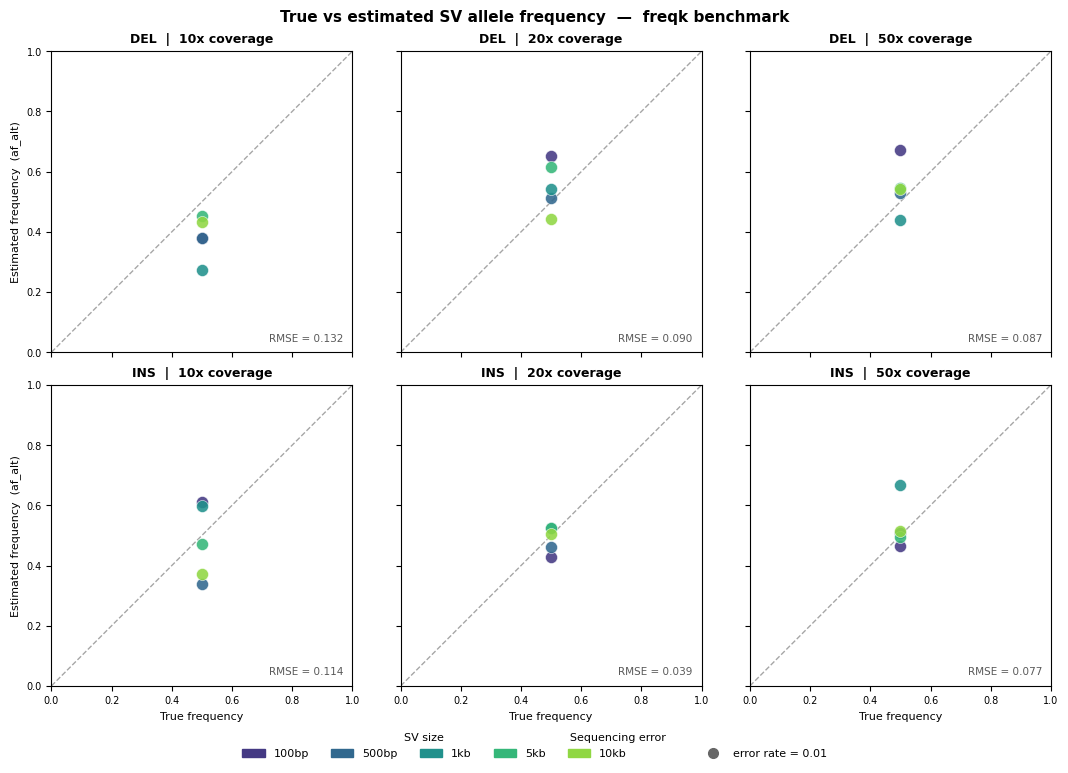

In [13]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

# ── Aesthetics ─────────────────────────────────────────────────────────────────
SIZE_ORDER  = ["100bp", "500bp", "1kb", "5kb", "10kb"]
palette = sns.color_palette("viridis", len(SIZE_ORDER))  # smooth gradient
SIZE_COLORS = dict(zip(SIZE_ORDER, palette))
ERR_MARKERS = {}   # filled in dynamically below

sv_types   = ["DEL", "INS"]
coverages  = sorted(results_df["coverage"].unique())
error_rates = sorted(results_df["error_rate"].unique())

# Assign markers to error rates
_markers = ["o", "s", "^", "D"]
for er, mk in zip(error_rates, _markers):
    ERR_MARKERS[er] = mk

# ── Layout: rows = sv_type, cols = coverage ────────────────────────────────────
nrows, ncols = len(sv_types), len(coverages)
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.6 * ncols, 3.6 * nrows),
    sharex=True, sharey=True,
    constrained_layout=True,
)
if nrows == 1: axes = [axes]
if ncols == 1: axes = [[ax] for ax in axes]

# Determine a shared axis range that includes the identity line
#all_vals = pd.concat([results_df["freq_nominal"], results_df["af_alt"]])
#pad = 0.06
#lo, hi = all_vals.min() - pad, all_vals.max() + pad
lo, hi = 0, 1
for i, svt in enumerate(sv_types):
    for j, cov in enumerate(coverages):
        ax = axes[i][j]
        subset = results_df[(results_df["sv_type"] == svt) & (results_df["coverage"] == cov)]

        for err in error_rates:
            for size in SIZE_ORDER:
                pts = subset[(subset["error_rate"] == err) & (subset["size"] == size)]
                if pts.empty:
                    continue
                ax.scatter(
                    pts["freq_nominal"], pts["af_alt"],
                    color=SIZE_COLORS.get(size, "grey"),
                    marker=ERR_MARKERS.get(err, "x"),
                    s=75, alpha=0.88,
                    edgecolors="white", linewidths=0.4,
                    zorder=3,
                )

        # Identity line (perfect estimation)
        ax.plot([lo, hi], [lo, hi], color="black", lw=1, ls="--", alpha=0.35, zorder=1)

        # RMSE annotation
        if not subset.empty:
            rmse = np.sqrt(((subset["af_alt"] - subset["freq_nominal"]) ** 2).mean())
            ax.text(0.97, 0.03, f"RMSE = {rmse:.3f}",
                    transform=ax.transAxes, ha="right", va="bottom",
                    fontsize=7.5, color="0.35",
                    bbox=dict(fc="white", ec="none", alpha=0.7, pad=1))

        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal")
        ax.set_title(f"{svt}  |  {cov}x coverage", fontsize=9, fontweight="bold")
        if j == 0:
            ax.set_ylabel("Estimated frequency  (af_alt)", fontsize=8)
        if i == nrows - 1:
            ax.set_xlabel("True frequency", fontsize=8)
        ax.tick_params(labelsize=7)

# ── Legends ────────────────────────────────────────────────────────────────────
size_patches = [mpatches.Patch(color=SIZE_COLORS[s], label=s) for s in SIZE_ORDER]
err_handles  = [
    mlines.Line2D([], [], color="0.4",
                  marker=ERR_MARKERS[e], linestyle="None",
                  markersize=7, label=f"error rate = {e}")
    for e in error_rates
]
fig.legend(
    handles=size_patches + [mpatches.Patch(visible=False)] + err_handles,
    title="SV size                                    Sequencing error",
    loc="lower center",
    ncol=len(SIZE_ORDER) + 1 + len(error_rates),
    fontsize=8,
    title_fontsize=8,
    bbox_to_anchor=(0.5, -0.06),
    frameon=False,
)

fig.suptitle("True vs estimated SV allele frequency  —  freqk benchmark",
             fontsize=11, fontweight="bold")

# ── Save ───────────────────────────────────────────────────────────────────────
#Path("plots").mkdir(exist_ok=True)
#fig.savefig("plots/true_vs_estimated.pdf", bbox_inches="tight")
#fig.savefig("plots/true_vs_estimated.png", bbox_inches="tight", dpi=150)0
plt.show()
#print("Saved to plots/true_vs_estimated.{pdf,png}")
